In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive')

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

# Bellabeat Leaf — Smart Device Usage Analysis
**Author:** Maral Alshanaa  
**Date:** April 2026  
**Tools:** Python · pandas · matplotlib · seaborn  
**Dashboard:** [Tableau Public — link after publishing]

---

## Business Task

Analyze FitBit smart device usage data to identify behavioral trends
in daily activity, sleep, and sedentary patterns among non-Bellabeat
users. Apply those insights to Bellabeat's **Leaf** product to inform
a data-driven marketing strategy targeting health-conscious women.

**Guiding questions:**
1. What are the key trends in smart device usage?
2. How could these trends apply to Bellabeat Leaf customers?
3. How could these trends influence Bellabeat's Leaf marketing strategy?

**Stakeholders:** Urška Sršen (CCO), Sando Mur (Co-founder),
Bellabeat Marketing Analytics Team.

In [3]:
# ── Install seaborn if needed (Colab usually has it) ──────────────────────────
# !pip install seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os

# ── Brand color palette (Bellabeat-inspired) ─────────────────────────────────
BRAND   = '#E97B6E'   # coral — primary Bellabeat color
ACCENT  = '#6B7FD7'   # soft blue
NEUTRAL = '#B0A8B9'   # muted lavender-gray
BG      = '#FAFAF8'   # off-white background
TEXT    = '#2C2C2A'   # near-black

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : '#D3D1C7',
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'text.color'       : TEXT,
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#E8E6DF',
    'grid.linewidth'   : 0.6,
})

# Create output folders
os.makedirs('visuals', exist_ok=True)
os.makedirs('tableau_exports', exist_ok=True)

print('✓ Libraries loaded')
print('✓ Style configured')
print('✓ Output folders ready')

✓ Libraries loaded
✓ Style configured
✓ Output folders ready


In [4]:
import os

files = os.listdir('.')  # or wherever you uploaded
csv_files = sorted([f for f in files if f.endswith('.csv')])
for f in csv_files:
  print(f)

In [5]:
import os

# Check all possible locations Colab stores uploaded files
for path in ['.', '/content', '/content/sample_data']:
    print(f'\n=== {path} ===')
    try:
        for f in sorted(os.listdir(path)):
            print(f)
    except:
        print('not found')


=== . ===
.config
drive
sample_data
tableau_exports
visuals

=== /content ===
.config
drive
sample_data
tableau_exports
visuals

=== /content/sample_data ===
README.md
anscombe.json
california_housing_test.csv
california_housing_train.csv
mnist_test.csv
mnist_train_small.csv


In [6]:
import os

# Change this to match your actual folder name on Drive
DRIVE_PATH = '/content/drive/MyDrive'

# Search for all CSVs recursively
print('Searching for CSV files in your Drive...\n')
for root, dirs, files in os.walk(DRIVE_PATH):
    for f in files:
        if f.endswith('.csv'):
            full_path = os.path.join(root, f)
            size = os.path.getsize(full_path)
            print(f'  {full_path}')
            print(f'  {size:>12,} bytes\n')

Searching for CSV files in your Drive...

  /content/drive/MyDrive/xA1VTx3eQrqNVU8d3kK6gA_d43b9c83af434f3d849ce2c1cef3e995_Example-Spreadsheet---Entertainment-Expenses---Sheet1 (1).csv
           134 bytes

  /content/drive/MyDrive/xA1VTx3eQrqNVU8d3kK6gA_d43b9c83af434f3d849ce2c1cef3e995_Example-Spreadsheet---Entertainment-Expenses---Sheet1.csv
           134 bytes

  /content/drive/MyDrive/health workforce statistics data.csv
     3,520,612 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/user/multi-modal-data-separate/cpu_july31_25min_rerun_800_8_graph_2.csv
         7,443 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separate/cpu_aug30_25min_800_9_graph_1.csv
       570,021 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separate/cpu_aug9_25min_400_2_graph_1.csv
    71,960,876 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separa

In [7]:
import os

BASE = '/content/drive/MyDrive/case_study'

os.makedirs(f'{BASE}/visuals', exist_ok=True)
os.makedirs(f'{BASE}/tableau_exports', exist_ok=True)
os.makedirs(f'{BASE}/notebooks', exist_ok=True)

print('✓ Folders ready on Drive:')
for folder in sorted(os.listdir(BASE)):
    print(f'  {BASE}/{folder}/')

✓ Folders ready on Drive:
  /content/drive/MyDrive/case_study/data/
  /content/drive/MyDrive/case_study/notebooks/
  /content/drive/MyDrive/case_study/tableau_exports/
  /content/drive/MyDrive/case_study/visuals/


In [8]:
import pandas as pd
import numpy as np
import os

# ── Base path — everything lives here ────────────────────────────────────────
BASE       = '/content/drive/MyDrive/case_study/data'
PATH_A     = f'{BASE}/3.12.16-4.11.16'
PATH_B     = f'{BASE}/4.12.16-5.12.16'
VIZ_PATH   = '/content/drive/MyDrive/case_study/visuals'
TAB_PATH   = '/content/drive/MyDrive/case_study/tableau_exports'
NB_PATH    = '/content/drive/MyDrive/case_study/notebooks'

# Create output folders if they don't exist yet
import os
os.makedirs(VIZ_PATH, exist_ok=True)
os.makedirs(TAB_PATH, exist_ok=True)
os.makedirs(NB_PATH, exist_ok=True)

print('✓ Paths configured')
print(f'  Data A : {PATH_A}')
print(f'  Data B : {PATH_B}')
print(f'  Visuals: {VIZ_PATH}')
print(f'  Tableau: {TAB_PATH}')
print(f'  Notebooks: {NB_PATH}')
print()

# Quick sanity check
print('PATH_A exists:', os.path.exists(PATH_A))
print('PATH_B exists:', os.path.exists(PATH_B))

# ── Helper: load from one or both folders depending on availability ───────────
def load_both(filename):
    path_a = f'{PATH_A}/{filename}'
    path_b = f'{PATH_B}/{filename}'

    exists_a = os.path.exists(path_a)
    exists_b = os.path.exists(path_b)

    if exists_a and exists_b:
        df = pd.concat([pd.read_csv(path_a), pd.read_csv(path_b)],
                       ignore_index=True).drop_duplicates()
        print(f'  ✓ {filename:45s} merged from both periods')
    elif exists_a:
        df = pd.read_csv(path_a)
        print(f'  ⚠ {filename:45s} found in period A only')
    elif exists_b:
        df = pd.read_csv(path_b)
        print(f'  ⚠ {filename:45s} found in period B only')
    else:
        raise FileNotFoundError(f'{filename} not found in either folder')

    return df

# ── CDC step classification ───────────────────────────────────────────────────
def classify_steps(s):
    if s < 5000:    return 'Sedentary'
    elif s < 7500:  return 'Low Active'
    elif s < 10000: return 'Somewhat Active'
    elif s < 12500: return 'Active'
    else:           return 'Highly Active'

# ── 1. Daily Activity ─────────────────────────────────────────────────────────
da = load_both('dailyActivity_cleaned.csv')
da['activity_date']         = pd.to_datetime(da['activity_date'])
da                          = da[da['calories'] > 0]
da['day_of_week']           = da['activity_date'].dt.day_name()
da['total_active_minutes']  = (da['very_active_minutes']
                                + da['fairly_active_minutes']
                                + da['lightly_active_minutes'])
da['total_tracked_minutes'] = da['total_active_minutes'] + da['sedentary_minutes']
da['sedentary_pct']         = (da['sedentary_minutes']
                                / da['total_tracked_minutes'] * 100).round(1)
da['activity_level']        = da['total_steps'].apply(classify_steps)

# ── 2. Sleep ──────────────────────────────────────────────────────────────────
sleep = load_both('sleepDay_cleaned.csv')
sleep['sleep_day']            = pd.to_datetime(sleep['sleep_day'])
sleep['minutes_awake_in_bed'] = (sleep['total_time_in_bed']
                                  - sleep['total_minutes_asleep'])
sleep['day_of_week']          = sleep['sleep_day'].dt.day_name()

# ── 3. Hourly Steps ───────────────────────────────────────────────────────────
hs = load_both('hourlySteps_cleaned.csv')
hs['activity_hour'] = pd.to_datetime(hs['activity_hour'])
hs['hour']          = hs['activity_hour'].dt.hour
hs['day_of_week']   = hs['activity_hour'].dt.day_name()

# ── 4. Hourly Calories ────────────────────────────────────────────────────────
hc = load_both('hourlyCalories_cleaned.csv')
hc['activity_hour'] = pd.to_datetime(hc['activity_hour'])
hc['hour']          = hc['activity_hour'].dt.hour

# ── 5. Hourly Intensities ─────────────────────────────────────────────────────
hi = load_both('hourlyIntensities_cleaned.csv')
hi['activity_hour'] = pd.to_datetime(hi['activity_hour'])
hi['hour']          = hi['activity_hour'].dt.hour

# ── 6. Weight Log ─────────────────────────────────────────────────────────────
wl = load_both('weightLogInfo_cleaned.csv')
wl['date'] = pd.to_datetime(wl['date'])

# ── Summary ───────────────────────────────────────────────────────────────────
print('✓ All cleaned datasets loaded and merged from both periods\n')
print(f'  Period A : {PATH_A.split("/")[-1]}')
print(f'  Period B : {PATH_B.split("/")[-1]}\n')
print(f'  Daily activity   → {da.shape[0]:>6,} rows | {da["id"].nunique()} users')
print(f'  Sleep            → {sleep.shape[0]:>6,} rows | {sleep["id"].nunique()} users')
print(f'  Hourly steps     → {hs.shape[0]:>6,} rows')
print(f'  Hourly calories  → {hc.shape[0]:>6,} rows')
print(f'  Hourly intensity → {hi.shape[0]:>6,} rows')
print(f'  Weight log       → {wl.shape[0]:>6,} rows | {wl["id"].nunique()} users (supplementary)')

✓ Paths configured
  Data A : /content/drive/MyDrive/case_study/data/3.12.16-4.11.16
  Data B : /content/drive/MyDrive/case_study/data/4.12.16-5.12.16
  Visuals: /content/drive/MyDrive/case_study/visuals
  Tableau: /content/drive/MyDrive/case_study/tableau_exports
  Notebooks: /content/drive/MyDrive/case_study/notebooks

PATH_A exists: True
PATH_B exists: True
  ✓ dailyActivity_cleaned.csv                     merged from both periods
  ⚠ sleepDay_cleaned.csv                          found in period B only
  ✓ hourlySteps_cleaned.csv                       merged from both periods
  ✓ hourlyCalories_cleaned.csv                    merged from both periods
  ✓ hourlyIntensities_cleaned.csv                 merged from both periods
  ✓ weightLogInfo_cleaned.csv                     merged from both periods
✓ All cleaned datasets loaded and merged from both periods

  Period A : 3.12.16-4.11.16
  Period B : 4.12.16-5.12.16

  Daily activity   →  1,388 rows | 35 users
  Sleep            →    41

## Descriptive Statistics — Key Takeaways

- The average user takes **7,328 steps/day** — 27% below the CDC's
  10,000-step recommendation. Only 7 of 35 users (20%) consistently
  hit that target.
- Users spend **990 minutes sedentary per day** — that is 16.5 hours,
  or 80.6% of their tracked day.
- Average sleep is **7.0 hours** — within the healthy range, but users
  spend an additional **39 minutes awake in bed** per night, pointing
  to poor sleep quality rather than poor sleep duration.
- One outlier: max `fairly_active_minutes` = 660 and max
  `lightly_active_minutes` = 720 — these are extreme values likely
  from a single very active user and will not affect averages
  meaningfully.

These four numbers tell the core Leaf story before a single chart
is drawn.

---
## Analysis 1 — Activity Patterns by Day of Week

**Question:** On which days of the week are users most active?

**Why it matters for Leaf:** If users are consistently less active
on certain days, Leaf's smart notifications and Bellabeat app
challenges can target those specific days to drive engagement.

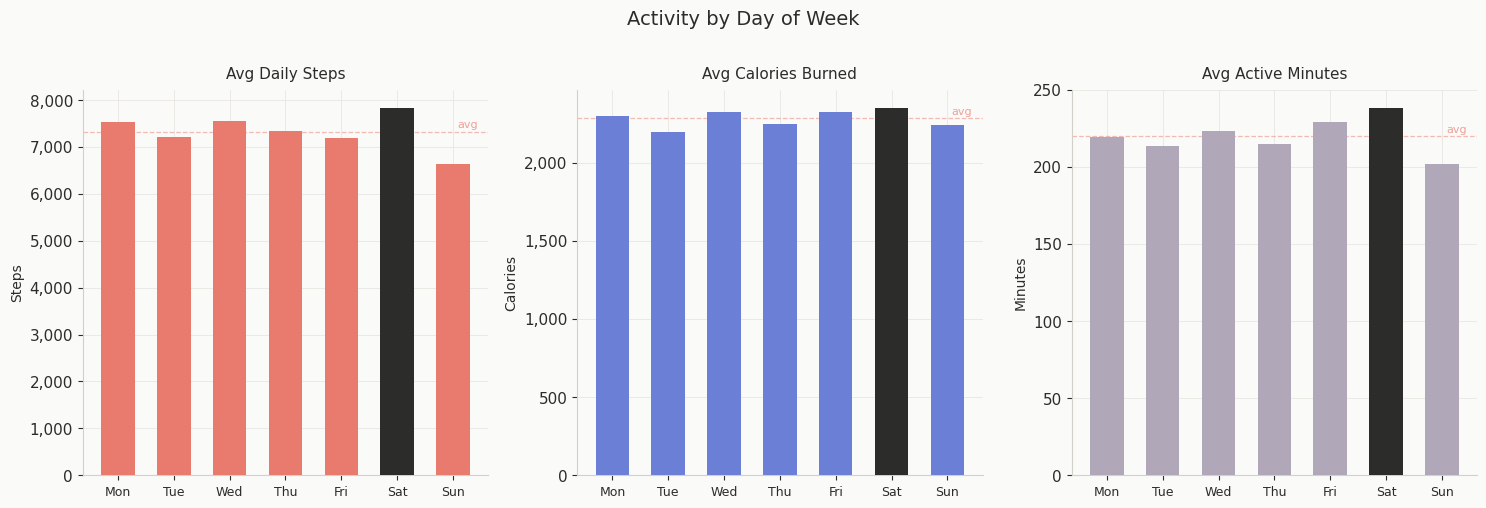

Avg steps by day:
  Monday        7,541  █████████████████████████
  Tuesday       7,212  ████████████████████████
  Wednesday     7,548  █████████████████████████
  Thursday      7,344  ████████████████████████
  Friday        7,188  ███████████████████████
  Saturday      7,831  ██████████████████████████
  Sunday        6,641  ██████████████████████

  Most active day:  Saturday (7,831 steps)
  Least active day: Sunday (6,641 steps)
  Difference:       1,190 steps

✓ Chart saved to Drive


In [9]:
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# ── Aggregate by day of week ──────────────────────────────────────────────────
steps_dow  = da.groupby('day_of_week')['total_steps'].mean().reindex(DAY_ORDER)
cal_dow    = da.groupby('day_of_week')['calories'].mean().reindex(DAY_ORDER)
active_dow = da.groupby('day_of_week')['total_active_minutes'].mean().reindex(DAY_ORDER)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Activity by Day of Week', fontsize=14, fontweight='500', y=1.01)

datasets   = [steps_dow,   cal_dow,              active_dow]
titles     = ['Avg Daily Steps', 'Avg Calories Burned', 'Avg Active Minutes']
ylabels    = ['Steps',       'Calories',           'Minutes']
bar_colors = [BRAND,         ACCENT,               NEUTRAL]

for ax, data, title, ylabel, color in zip(axes, datasets, titles, ylabels, bar_colors):
    # highlight max bar
    colors = [color if v != data.max() else TEXT for v in data.values]
    bars   = ax.bar(DAY_ORDER, data.values, color=colors, width=0.6, zorder=3)
    # average reference line
    ax.axhline(data.mean(), color=BRAND, linewidth=0.9,
               linestyle='--', alpha=0.5, zorder=2)
    ax.text(6.45, data.mean() * 1.012, 'avg',
            fontsize=8, color=BRAND, alpha=0.7, ha='right')
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(DAY_ORDER)))
    ax.set_xticklabels([d[:3] for d in DAY_ORDER], fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/01_activity_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('Avg steps by day:')
for day, val in steps_dow.items():
    bar = '█' * int(val / 300)
    print(f'  {day:<12} {val:>6,.0f}  {bar}')
print(f'\n  Most active day:  {steps_dow.idxmax()} ({steps_dow.max():,.0f} steps)')
print(f'  Least active day: {steps_dow.idxmin()} ({steps_dow.min():,.0f} steps)')
print(f'  Difference:       {steps_dow.max() - steps_dow.min():,.0f} steps')
print(f'\n✓ Chart saved to Drive')

**Finding 1:** Saturday is the most active day (7,831 avg steps)
and Sunday the least active (6,641 avg steps) — a difference of
1,190 steps. Weekdays cluster tightly between 7,100–7,550 steps
with Friday being the lowest weekday. Activity is consistently
below the CDC's 10,000-step target every single day of the week.

> **Leaf implication:** No single day hits the CDC target on
> average — this is not a weekend vs weekday problem, it is an
> every-day problem. Bellabeat should market Leaf's daily
> inactivity alerts as a 7-day solution, not just a weekend
> motivator. Low-activity days (Sunday and Friday) are the best
> days to send Bellabeat app challenges and push notifications.

---
## Analysis 2 — Hourly Activity Peaks

**Question:** At what hours of the day are users most active?

**Why it matters for Leaf:** Knowing peak movement windows tells
us the optimal times for Leaf notifications and app push alerts
to feel relevant rather than intrusive.

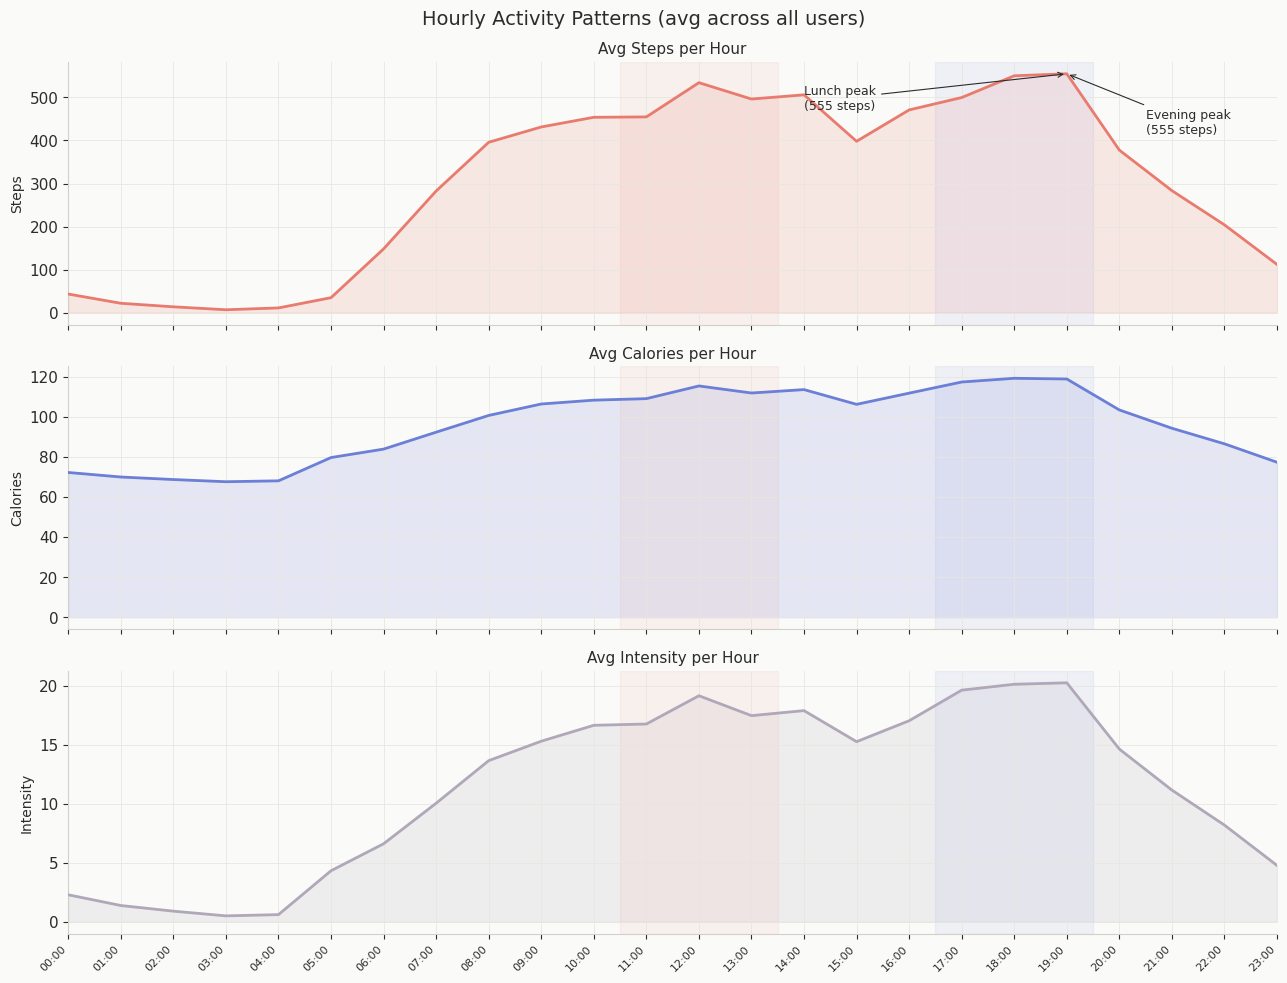

Top 5 most active hours (by steps):
  7pm       555 steps  ██████████████████████
  6pm       550 steps  ██████████████████████
  12pm      534 steps  █████████████████████
  2pm       506 steps  ████████████████████
  5pm       500 steps  ███████████████████

Quietest hours (midnight–5am avg): 22 steps
Peak vs quiet difference:          533 steps

✓ Chart saved to Drive


In [10]:
# ── Aggregate by hour ─────────────────────────────────────────────────────────
hourly_steps = hs.groupby('hour')['step_total'].mean()
hourly_cal   = hc.groupby('hour')['calories'].mean()
hourly_int   = hi.groupby('hour')['total_intensity'].mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Hourly Activity Patterns (avg across all users)',
             fontsize=14, fontweight='500')

hours       = range(24)
hour_labels = [f'{h:02d}:00' for h in hours]

datasets = [
    (hourly_steps, 'Avg Steps per Hour',     BRAND,   'Steps'),
    (hourly_cal,   'Avg Calories per Hour',  ACCENT,  'Calories'),
    (hourly_int,   'Avg Intensity per Hour', NEUTRAL, 'Intensity'),
]

# peak windows based on data
lunch_peak   = (11, 13)
evening_peak = (17, 19)

for ax, (data, title, color, ylabel) in zip(axes, datasets):
    ax.fill_between(hours, data.values, alpha=0.15, color=color)
    ax.plot(hours, data.values, color=color, linewidth=2, zorder=3)
    # shade peak windows
    ax.axvspan(lunch_peak[0]   - 0.5, lunch_peak[1]   + 0.5,
               color=BRAND, alpha=0.08, zorder=1, label='Lunch peak')
    ax.axvspan(evening_peak[0] - 0.5, evening_peak[1] + 0.5,
               color=ACCENT, alpha=0.08, zorder=1, label='Evening peak')
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(0, 23)

axes[-1].set_xticks(list(hours))
axes[-1].set_xticklabels(hour_labels, rotation=45, ha='right', fontsize=8)

# annotations on top subplot only
peak_hour_steps = hourly_steps.idxmax()
axes[0].annotate(
    f'Lunch peak\n({hourly_steps[peak_hour_steps]:,.0f} steps)',
    xy=(peak_hour_steps, hourly_steps[peak_hour_steps]),
    xytext=(peak_hour_steps - 5, hourly_steps.max() * 0.85),
    arrowprops=dict(arrowstyle='->', color=TEXT, lw=0.8),
    fontsize=9, color=TEXT
)
evening_hour = hourly_steps.loc[17:19].idxmax()
axes[0].annotate(
    f'Evening peak\n({hourly_steps[evening_hour]:,.0f} steps)',
    xy=(evening_hour, hourly_steps[evening_hour]),
    xytext=(evening_hour + 1.5, hourly_steps.max() * 0.75),
    arrowprops=dict(arrowstyle='->', color=TEXT, lw=0.8),
    fontsize=9, color=TEXT
)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/02_hourly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('Top 5 most active hours (by steps):')
top5 = hourly_steps.nlargest(5)
for hour, val in top5.items():
    ampm = f'{hour}am' if hour < 12 else f'{hour-12 if hour>12 else 12}pm'
    bar  = '█' * int(val / 25)
    print(f'  {ampm:<6} {val:>6,.0f} steps  {bar}')

print(f'\nQuietest hours (midnight–5am avg): '
      f'{hourly_steps.loc[0:5].mean():,.0f} steps')
print(f'Peak vs quiet difference:          '
      f'{hourly_steps.max() - hourly_steps.loc[0:5].mean():,.0f} steps')
print(f'\n✓ Chart saved to Drive')

**Finding 2:** Activity peaks in two clear windows every day —  
**lunch (12pm)** and **early evening (5–7pm)**, with 7pm being  
the single most active hour (555 avg steps). Users are nearly  
inactive between midnight and 5am (avg 22 steps/hour), and the  
difference between peak and quiet hours is 533 steps.

> **Leaf implication:** Leaf's inactivity reminders should fire  
> at **10:30am** and **4pm** — just before the natural peaks —  
> to prime users for their existing movement windows. These are  
> not new habits to build, just natural rhythms to amplify.  
> Marketing can position Leaf as a product that *"works with  
> your body clock, not against it."*

---
## Analysis 3 — Sleep Quality

**Question:** How well are users sleeping, and is there a weekly
pattern?

**Why it matters for Leaf:** The Leaf tracks sleep alongside
activity and stress. Poor sleep quality is a direct marketing
hook — users who struggle to sleep well are the core Leaf
audience.

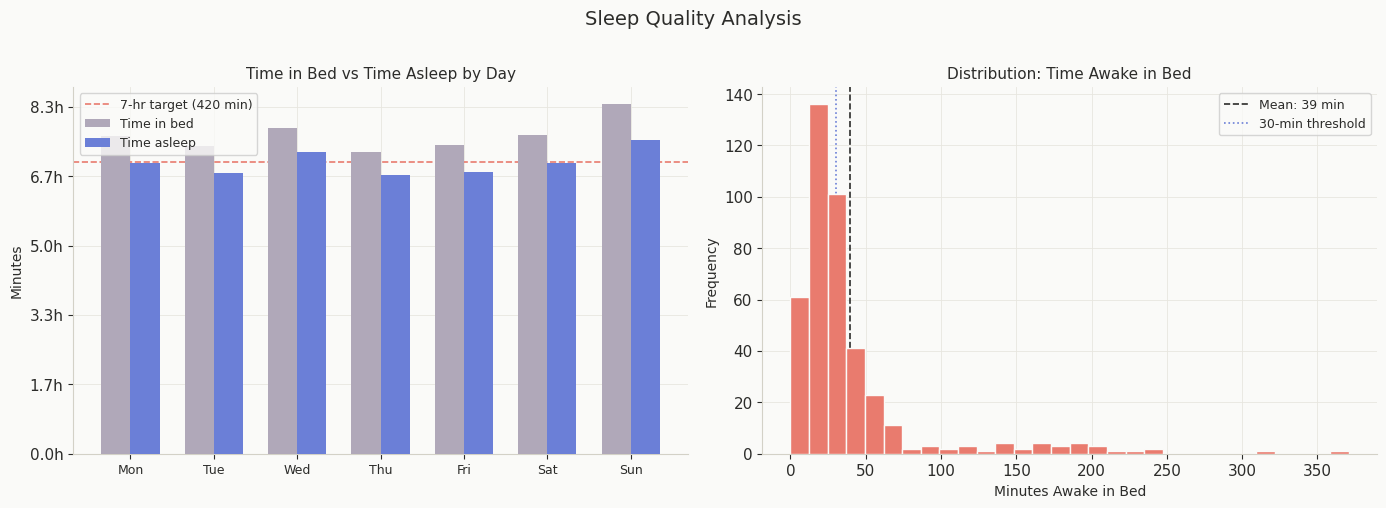

Sleep quality by day of week:
  Day            In Bed   Asleep    Awake
  ----------------------------------------
  Monday          7.6h     7.0h    37.8min
  Tuesday         7.4h     6.7h    38.8min
  Wednesday       7.8h     7.2h    35.3min
  Thursday        7.2h     6.7h    33.6min
  Friday          7.4h     6.8h    39.6min
  Saturday        7.7h     7.0h    40.8min
  Sunday          8.4h     7.5h    50.8min

  Overall avg time asleep:    7.0 hrs
  Overall avg time in bed:    7.6 hrs
  Overall avg awake in bed:   39 min

  Users averaging >30 min awake in bed: 10 of 24

✓ Chart saved to Drive


In [11]:
# ── Aggregate sleep by day of week ────────────────────────────────────────────
sleep_dow = sleep.groupby('day_of_week').agg(
    avg_asleep = ('total_minutes_asleep', 'mean'),
    avg_in_bed = ('total_time_in_bed',    'mean'),
    avg_awake  = ('minutes_awake_in_bed', 'mean')
).reindex(DAY_ORDER).round(1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sleep Quality Analysis', fontsize=14, fontweight='500', y=1.01)

# ── Left: asleep vs in-bed by weekday ────────────────────────────────────────
ax  = axes[0]
x   = range(len(DAY_ORDER))
w   = 0.35
ax.bar([i - w/2 for i in x], sleep_dow['avg_in_bed'],
       width=w, label='Time in bed', color=NEUTRAL, zorder=3)
ax.bar([i + w/2 for i in x], sleep_dow['avg_asleep'],
       width=w, label='Time asleep', color=ACCENT,  zorder=3)
ax.axhline(420, color=BRAND, linewidth=1.2,
           linestyle='--', label='7-hr target (420 min)')
ax.set_xticks(list(x))
ax.set_xticklabels([d[:3] for d in DAY_ORDER], fontsize=9)
ax.set_ylabel('Minutes', fontsize=10)
ax.set_title('Time in Bed vs Time Asleep by Day', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/60:.1f}h'))
ax.legend(fontsize=9)

# ── Right: distribution of minutes awake in bed ───────────────────────────────
ax2 = axes[1]
ax2.hist(sleep['minutes_awake_in_bed'], bins=30,
         color=BRAND, edgecolor=BG, zorder=3)
ax2.axvline(sleep['minutes_awake_in_bed'].mean(),
            color=TEXT, linewidth=1.2, linestyle='--',
            label=f"Mean: {sleep['minutes_awake_in_bed'].mean():.0f} min")
ax2.axvline(30, color=ACCENT, linewidth=1.2, linestyle=':',
            label='30-min threshold')
ax2.set_xlabel('Minutes Awake in Bed', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Distribution: Time Awake in Bed', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/03_sleep_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('Sleep quality by day of week:')
print(f'  {"Day":<12} {"In Bed":>8} {"Asleep":>8} {"Awake":>8}')
print('  ' + '-' * 40)
for day in DAY_ORDER:
    row = sleep_dow.loc[day]
    print(f'  {day:<12} '
          f'{row["avg_in_bed"]/60:>6.1f}h  '
          f'{row["avg_asleep"]/60:>6.1f}h  '
          f'{row["avg_awake"]:>6.1f}min')

print(f'\n  Overall avg time asleep:    '
      f'{sleep["total_minutes_asleep"].mean()/60:.1f} hrs')
print(f'  Overall avg time in bed:    '
      f'{sleep["total_time_in_bed"].mean()/60:.1f} hrs')
print(f'  Overall avg awake in bed:   '
      f'{sleep["minutes_awake_in_bed"].mean():.0f} min')
print(f'\n  Users averaging >30 min awake in bed: '
      f'{(sleep.groupby("id")["minutes_awake_in_bed"].mean() > 30).sum()}'
      f' of {sleep["id"].nunique()}')
print(f'\n✓ Chart saved to Drive')

**Finding 3:** Users average **7.0 hours asleep** but spend
**7.6 hours in bed** — meaning 39 minutes per night are spent
awake in bed. Over 10 of the 24 sleep-tracking users average
more than 30 minutes awake in bed, suggesting chronic
restlessness.

A standout pattern: **Sunday has the worst sleep quality**
despite being the longest night in bed (8.4 hrs). Users spend
50.8 minutes awake in bed on Sundays — 27% more restlessness
than the weekly average. Tuesday and Thursday also show lower
sleep duration (6.7 hrs) suggesting mid-week sleep debt.

> **Leaf implication:** Two distinct marketing angles emerge
> from this data. First, the overall sleep gap — position
> Leaf as the tool that *"helps you understand why you feel
> tired even after 8 hours."* Second, Sunday-specific
> restlessness — Bellabeat's app can send a Sunday evening
> wind-down reminder tied to Leaf's stress tracking feature,
> marketed as *"Start your week rested. Leaf helps you
> switch off."*

---
## Analysis 4 — Sedentary Behavior

**Question:** How sedentary are users throughout the day, and
how does it vary across the user base?

**Why it matters for Leaf:** Sedentary behavior is Leaf's core
value proposition — the product is worn all day and passively
tracks inactivity. This analysis quantifies how severe and
universal the problem is.

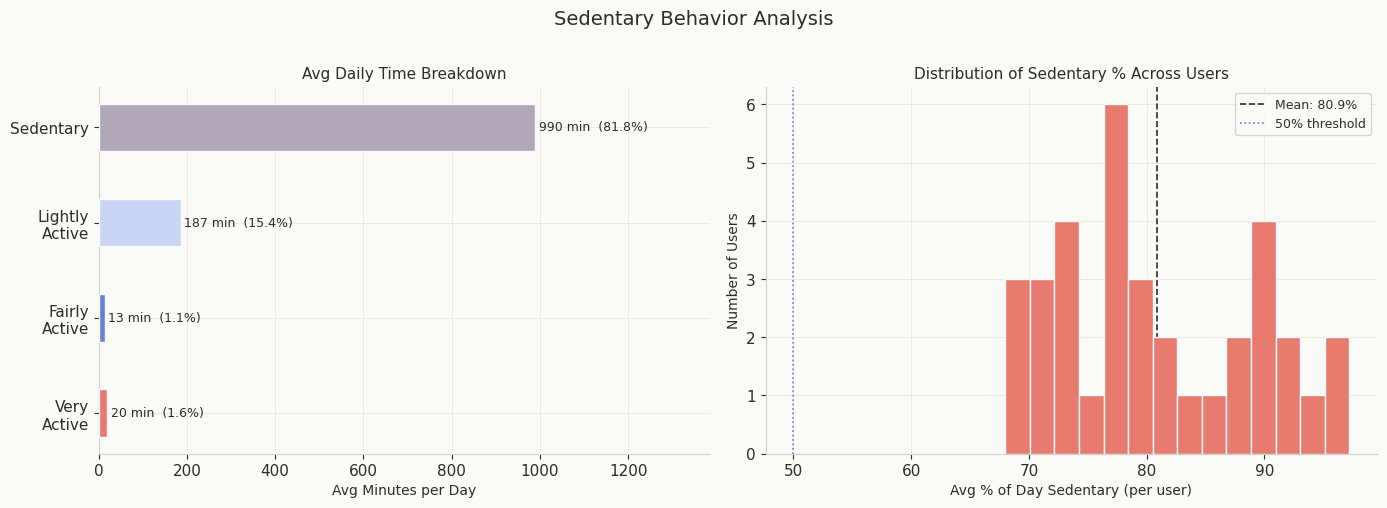

Daily time breakdown (avg across all users):
  Category            Minutes   Hours   % of day
  ----------------------------------------------
  Sedentary               990    16.5h      81.8%
  Lightly Active          187     3.1h      15.4%
  Fairly Active            13     0.2h       1.1%
  Very Active              20     0.3h       1.6%

  Total tracked time/day:  1210 min (20.2 hrs)

  Users with >75% sedentary time: 25 of 35
  Users with >90% sedentary time: 5 of 35
  Most sedentary user avg:  97.2% of day sedentary
  Least sedentary user avg: 68.0% of day sedentary

✓ Chart saved to Drive


In [12]:
# ── Per-user averages ─────────────────────────────────────────────────────────
user_avg = da.groupby('id').agg(
    avg_steps     = ('total_steps',          'mean'),
    avg_sedentary = ('sedentary_minutes',     'mean'),
    avg_active    = ('total_active_minutes',  'mean'),
    avg_sedpct    = ('sedentary_pct',         'mean'),
    avg_calories  = ('calories',              'mean'),
).round(1)

# ── Overall daily time breakdown ──────────────────────────────────────────────
avg_sed   = da['sedentary_minutes'].mean()
avg_light = da['lightly_active_minutes'].mean()
avg_fair  = da['fairly_active_minutes'].mean()
avg_very  = da['very_active_minutes'].mean()
total     = avg_sed + avg_light + avg_fair + avg_very

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sedentary Behavior Analysis',
             fontsize=14, fontweight='500', y=1.01)

# ── Left: horizontal bar — daily time breakdown ───────────────────────────────
ax     = axes[0]
labels = ['Sedentary', 'Lightly\nActive', 'Fairly\nActive', 'Very\nActive']
values = [avg_sed, avg_light, avg_fair, avg_very]
colors = [NEUTRAL, '#C8D5F5', ACCENT, BRAND]
bars   = ax.barh(labels, values, color=colors,
                 edgecolor=BG, height=0.5, zorder=3)

for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(bar.get_width() + 8,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} min  ({pct:.1f}%)',
            va='center', fontsize=9)

ax.set_xlabel('Avg Minutes per Day', fontsize=10)
ax.set_title('Avg Daily Time Breakdown', fontsize=11)
ax.set_xlim(0, avg_sed * 1.4)
ax.invert_yaxis()

# ── Right: histogram of sedentary % per user ──────────────────────────────────
ax2 = axes[1]
ax2.hist(user_avg['avg_sedpct'], bins=14,
         color=BRAND, edgecolor=BG, zorder=3)
ax2.axvline(user_avg['avg_sedpct'].mean(),
            color=TEXT, linewidth=1.2, linestyle='--',
            label=f"Mean: {user_avg['avg_sedpct'].mean():.1f}%")
ax2.axvline(50, color=ACCENT, linewidth=1.2, linestyle=':',
            label='50% threshold')
ax2.set_xlabel('Avg % of Day Sedentary (per user)', fontsize=10)
ax2.set_ylabel('Number of Users', fontsize=10)
ax2.set_title('Distribution of Sedentary % Across Users', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/04_sedentary_behavior.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('Daily time breakdown (avg across all users):')
print(f'  {"Category":<18} {"Minutes":>8} {"Hours":>7} {"% of day":>10}')
print('  ' + '-' * 46)
for label, val in zip(labels, values):
    clean_label = label.replace('\n', ' ')
    print(f'  {clean_label:<18} {val:>8.0f} {val/60:>7.1f}h {val/total*100:>9.1f}%')

print(f'\n  Total tracked time/day:  {total:.0f} min ({total/60:.1f} hrs)')
print(f'\n  Users with >75% sedentary time: '
      f'{(user_avg["avg_sedpct"] > 75).sum()} of {len(user_avg)}')
print(f'  Users with >90% sedentary time: '
      f'{(user_avg["avg_sedpct"] > 90).sum()} of {len(user_avg)}')
print(f'  Most sedentary user avg:  '
      f'{user_avg["avg_sedpct"].max():.1f}% of day sedentary')
print(f'  Least sedentary user avg: '
      f'{user_avg["avg_sedpct"].min():.1f}% of day sedentary')
print(f'\n✓ Chart saved to Drive')

**Finding 4:** Users spend an average of **990 minutes (16.5
hours) sedentary per day** — approximately **81.8% of their
tracked time**. Very active minutes average only 20 min/day
while fairly active minutes average just 13 min/day.

Critically, this is not an outlier problem — it is universal:
- **71% of users** (25 of 35) spend more than 75% of their
  day sedentary
- **5 users** spend over 90% of their day sedentary
- Even the **least sedentary user** is still 68% inactive
- The range spans 68%–97%, meaning no user escapes the problem

> **Leaf implication:** This is the single most powerful
> finding for Leaf marketing. The problem is universal — not
> a niche issue. Bellabeat should lead with this statistic
> in campaigns: *"Most women sit for over 16 hours a day
> without realising it. Leaf does."* Smart inactivity alerts
> are Leaf's most compelling feature to promote — and this
> data proves exactly why. The 5 highly sedentary users
> (>90%) represent a high-priority segment for Leaf's
> membership tier offering personalised coaching.

---
## Analysis 5 — User Segmentation by Activity Level

**Question:** What proportion of users fall into each activity
category based on their average daily steps?

**Why it matters for Leaf:** Understanding the distribution of
user types helps Bellabeat identify its primary target segment
and tailor Leaf messaging to speak directly to them.

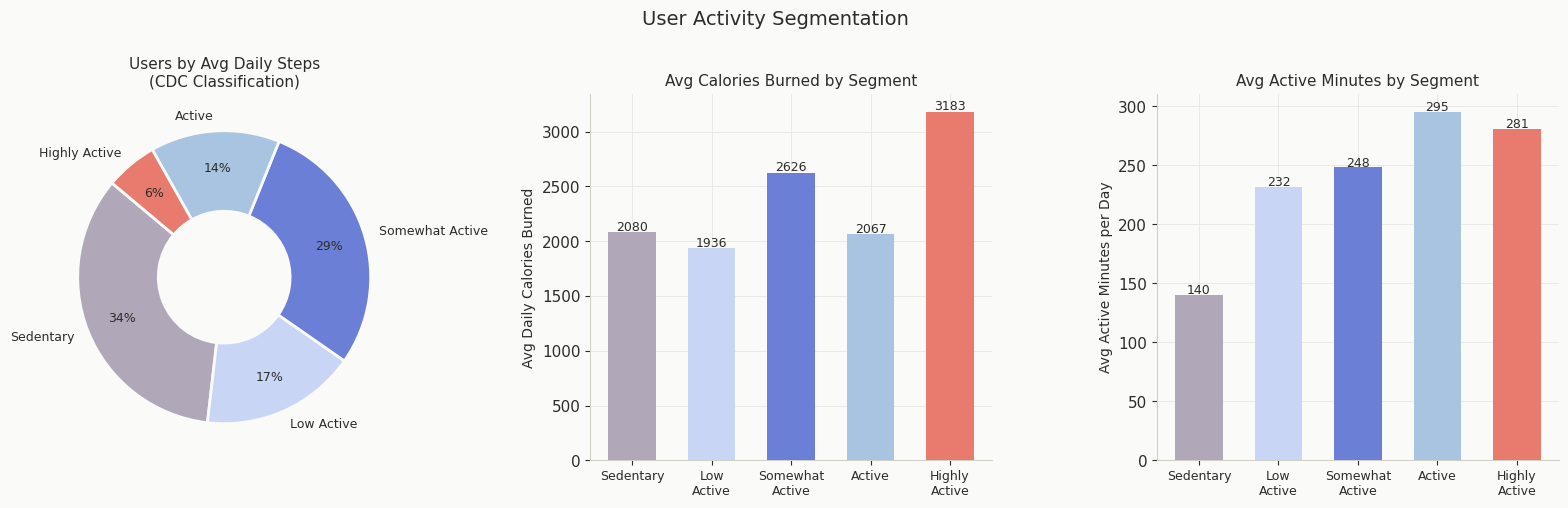

User segments by avg daily steps (CDC classification):

  Segment             Users  % of total   Avg steps  Avg calories
  --------------------------------------------------------------
  Sedentary              12       34.3%       3,402         2,080
  Low Active              6       17.1%       6,370         1,936
  Somewhat Active        10       28.6%       8,353         2,626
  Active                  5       14.3%      11,295         2,067
  Highly Active           2        5.7%      15,614         3,183

  Below 7,500 steps/day (Sedentary + Low Active): 18 users (51%)
  Above 10,000 steps/day (Active + Highly Active): 7 users (20%)

✓ Chart saved to Drive


In [13]:
SEGMENT_ORDER  = ['Sedentary', 'Low Active', 'Somewhat Active',
                  'Active', 'Highly Active']
SEGMENT_COLORS = [NEUTRAL, '#C8D5F5', ACCENT, '#A8C4E0', BRAND]

# ── Segment each user by their average daily steps ────────────────────────────
user_segment = (da.groupby('id')['total_steps']
                  .mean()
                  .apply(classify_steps))
seg_counts   = (user_segment
                .value_counts()
                .reindex(SEGMENT_ORDER)
                .fillna(0)
                .astype(int))

# ── Map segment back to daily rows for calorie comparison ─────────────────────
da['user_segment'] = da['id'].map(user_segment)
seg_cal = (da.groupby('user_segment')['calories']
             .mean()
             .reindex(SEGMENT_ORDER))
seg_act = (da.groupby('user_segment')['total_active_minutes']
             .mean()
             .reindex(SEGMENT_ORDER))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('User Activity Segmentation',
             fontsize=14, fontweight='500', y=1.01)

# ── Left: donut chart ─────────────────────────────────────────────────────────
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    seg_counts,
    labels=SEGMENT_ORDER,
    autopct='%1.0f%%',
    colors=SEGMENT_COLORS,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    pctdistance=0.75,
)
for t in texts:     t.set_fontsize(9)
for t in autotexts: t.set_fontsize(9)
ax.set_title('Users by Avg Daily Steps\n(CDC Classification)',
             fontsize=11)

# ── Middle: avg calories per segment ──────────────────────────────────────────
ax2   = axes[1]
bars2 = ax2.bar(SEGMENT_ORDER, seg_cal,
                color=SEGMENT_COLORS, zorder=3, width=0.6)
ax2.set_ylabel('Avg Daily Calories Burned', fontsize=10)
ax2.set_title('Avg Calories Burned by Segment', fontsize=11)
ax2.set_xticks(range(len(SEGMENT_ORDER)))
ax2.set_xticklabels(
    [s.replace(' ', '\n') for s in SEGMENT_ORDER], fontsize=9)
for bar, val in zip(bars2, seg_cal):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 15,
             f'{val:.0f}', ha='center', fontsize=9)

# ── Right: avg active minutes per segment ─────────────────────────────────────
ax3   = axes[2]
bars3 = ax3.bar(SEGMENT_ORDER, seg_act,
                color=SEGMENT_COLORS, zorder=3, width=0.6)
ax3.set_ylabel('Avg Active Minutes per Day', fontsize=10)
ax3.set_title('Avg Active Minutes by Segment', fontsize=11)
ax3.set_xticks(range(len(SEGMENT_ORDER)))
ax3.set_xticklabels(
    [s.replace(' ', '\n') for s in SEGMENT_ORDER], fontsize=9)
for bar, val in zip(bars3, seg_act):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/05_user_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('User segments by avg daily steps (CDC classification):')
print(f'\n  {"Segment":<18} {"Users":>6} {"% of total":>11} '
      f'{"Avg steps":>11} {"Avg calories":>13}')
print('  ' + '-' * 62)

for seg in SEGMENT_ORDER:
    count = seg_counts[seg]
    pct   = count / len(user_segment) * 100
    avg_s = da[da['user_segment'] == seg]['total_steps'].mean()
    avg_c = da[da['user_segment'] == seg]['calories'].mean()
    print(f'  {seg:<18} {count:>6} {pct:>10.1f}% '
          f'{avg_s:>11,.0f} {avg_c:>13,.0f}')

below_target = seg_counts['Sedentary'] + seg_counts['Low Active']
above_target = seg_counts['Active']    + seg_counts['Highly Active']
print(f'\n  Below 7,500 steps/day (Sedentary + Low Active): '
      f'{below_target} users '
      f'({below_target/len(user_segment)*100:.0f}%)')
print(f'  Above 10,000 steps/day (Active + Highly Active): '
      f'{above_target} users '
      f'({above_target/len(user_segment)*100:.0f}%)')
print(f'\n✓ Chart saved to Drive')

**Finding 5:** The Sedentary segment is the single largest group
at **34.3% of users** (12 of 35). Combined with Low Active users,
**51% of all users never reach 7,500 daily steps**. Only 7 users
(20%) consistently hit the Active or Highly Active threshold, and
just 2 users (5.7%) qualify as Highly Active.

The data shows a clear bottom-heavy distribution — most users
cluster in the lower activity segments, not the top.

> **Leaf implication:** Bellabeat's primary Leaf target is
> overwhelmingly the **Sedentary and Low Active** segment —
> women who want to be healthier but are not there yet.
> Marketing should avoid language targeting elite athletes
> and instead speak to the aspirational moderate: *"Not a
> runner. Not a couch. Just living life — and Leaf helps
> you live it better."*  
> The **Somewhat Active segment (28.6%)** is the prime
> upgrade audience for Bellabeat's membership tier — they
> are already engaged enough to want personalised guidance
> to push them into the Active range.

---
## Analysis 6 — Activity vs Sleep Correlation

**Question:** Do more active users sleep better?

**Why it matters for Leaf:** The Leaf tracks both activity and
sleep. If a relationship exists between the two, it reinforces
the product's holistic wellness narrative and gives Bellabeat
a data-backed story to tell in marketing.

Users in merged dataset: 24 (users with both activity and sleep data)


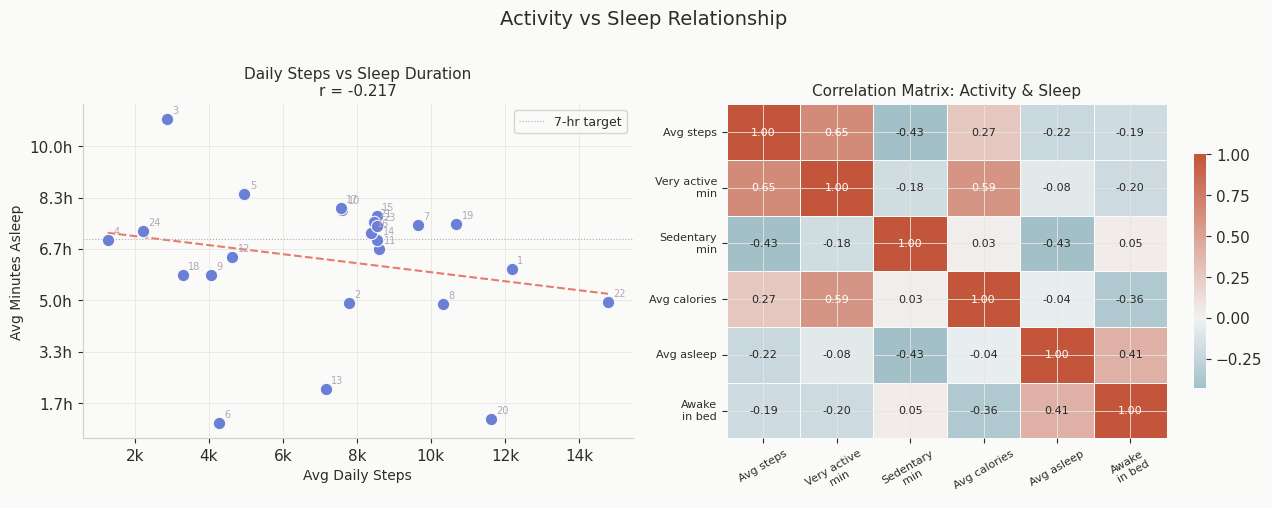

Correlations with avg minutes asleep:
  Variable                   r value  Interpretation
  ------------------------------------------------------------
  Avg daily steps             -0.217  weak negative
  Very active minutes         -0.078  negligible
  Sedentary minutes           -0.425  moderate negative
  Avg calories burned         -0.043  negligible
  Avg active minutes          -0.220  weak negative

Correlations with avg minutes awake in bed:
  Variable                   r value  Interpretation
  ------------------------------------------------------------
  Avg daily steps             -0.195  weak negative
  Very active minutes         -0.198  weak negative
  Sedentary minutes            0.051  negligible
  Avg calories burned         -0.364  moderate negative

✓ Chart saved to Drive


In [14]:
# ── Per-user averages for both datasets ───────────────────────────────────────
da_avg    = da.groupby('id').agg(
    avg_steps           = ('total_steps',          'mean'),
    avg_very_active     = ('very_active_minutes',  'mean'),
    avg_sedentary       = ('sedentary_minutes',     'mean'),
    avg_calories        = ('calories',              'mean'),
    avg_active_minutes  = ('total_active_minutes',  'mean'),
).round(1)

sleep_avg = sleep.groupby('id').agg(
    avg_asleep  = ('total_minutes_asleep',  'mean'),
    avg_in_bed  = ('total_time_in_bed',     'mean'),
    avg_awake   = ('minutes_awake_in_bed',  'mean'),
).round(1)

# ── Merge on id — only users present in both datasets ────────────────────────
merged = da_avg.merge(sleep_avg, on='id')
print(f'Users in merged dataset: {len(merged)} '
      f'(users with both activity and sleep data)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Activity vs Sleep Relationship',
             fontsize=14, fontweight='500', y=1.01)

# ── Left: scatter — steps vs minutes asleep ───────────────────────────────────
ax = axes[0]
ax.scatter(merged['avg_steps'], merged['avg_asleep'],
           color=ACCENT, s=80, edgecolors=BG,
           linewidths=0.8, zorder=3)

# label each dot with user index for transparency
for i, (idx, row) in enumerate(merged.iterrows()):
    ax.annotate(str(i+1),
                (row['avg_steps'], row['avg_asleep']),
                fontsize=7, color=NEUTRAL,
                xytext=(4, 4), textcoords='offset points')

# trend line
m, b = np.polyfit(merged['avg_steps'], merged['avg_asleep'], 1)
xs   = np.linspace(merged['avg_steps'].min(),
                   merged['avg_steps'].max(), 100)
ax.plot(xs, m*xs + b, color=BRAND,
        linewidth=1.5, linestyle='--', zorder=2)

r = merged['avg_steps'].corr(merged['avg_asleep'])
ax.set_xlabel('Avg Daily Steps', fontsize=10)
ax.set_ylabel('Avg Minutes Asleep', fontsize=10)
ax.set_title(f'Daily Steps vs Sleep Duration\nr = {r:.3f}',
             fontsize=11)
ax.axhline(420, color=NEUTRAL, linewidth=0.8,
           linestyle=':', label='7-hr target')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/60:.1f}h'))
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(fontsize=9)

# ── Right: correlation heatmap ────────────────────────────────────────────────
ax2       = axes[1]
corr_cols = ['avg_steps', 'avg_very_active', 'avg_sedentary',
             'avg_calories', 'avg_asleep', 'avg_awake']
corr_labels = ['Avg steps', 'Very active\nmin', 'Sedentary\nmin',
               'Avg calories', 'Avg asleep', 'Awake\nin bed']
corr_matrix = merged[corr_cols].corr().round(2)
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

sns.heatmap(
    corr_matrix,
    ax=ax2,
    annot=True,
    fmt='.2f',
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    linewidths=0.5,
    linecolor=BG,
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 8},
)
ax2.set_title('Correlation Matrix: Activity & Sleep', fontsize=11)
ax2.tick_params(axis='x', rotation=30, labelsize=8)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/06_activity_vs_sleep.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print all correlations with sleep ────────────────────────────────────────
print('Correlations with avg minutes asleep:')
print(f'  {"Variable":<25} {"r value":>8}  Interpretation')
print('  ' + '-' * 60)

correlations = [
    ('Avg daily steps',      merged['avg_steps'].corr(merged['avg_asleep'])),
    ('Very active minutes',  merged['avg_very_active'].corr(merged['avg_asleep'])),
    ('Sedentary minutes',    merged['avg_sedentary'].corr(merged['avg_asleep'])),
    ('Avg calories burned',  merged['avg_calories'].corr(merged['avg_asleep'])),
    ('Avg active minutes',   merged['avg_active_minutes'].corr(merged['avg_asleep'])),
]

def interpret(r):
    a = abs(r)
    direction = 'positive' if r > 0 else 'negative'
    if a < 0.1:   return 'negligible'
    elif a < 0.3: return f'weak {direction}'
    elif a < 0.5: return f'moderate {direction}'
    else:         return f'strong {direction}'

for label, r in correlations:
    print(f'  {label:<25} {r:>8.3f}  {interpret(r)}')

print(f'\nCorrelations with avg minutes awake in bed:')
print(f'  {"Variable":<25} {"r value":>8}  Interpretation')
print('  ' + '-' * 60)

correlations_awake = [
    ('Avg daily steps',     merged['avg_steps'].corr(merged['avg_awake'])),
    ('Very active minutes', merged['avg_very_active'].corr(merged['avg_awake'])),
    ('Sedentary minutes',   merged['avg_sedentary'].corr(merged['avg_awake'])),
    ('Avg calories burned', merged['avg_calories'].corr(merged['avg_awake'])),
]

for label, r in correlations_awake:
    print(f'  {label:<25} {r:>8.3f}  {interpret(r)}')

print(f'\n✓ Chart saved to Drive')

**Finding 6:** Most correlations between activity and sleep are
weak, but two moderate relationships stand out:

1. **Sedentary minutes vs sleep duration: r = -0.425** — users
   who spend more time sedentary tend to sleep *less* overall.
   More sitting = less sleep.
2. **Calories burned vs awake in bed: r = -0.364** — users who
   burn more calories spend *less time* restless in bed. More
   movement = more restful sleep.

The relationship between activity and sleep is not about
duration — it is about **quality**. Active users do not
necessarily sleep longer, but they sleep more soundly.

> **Leaf implication:** This gives Bellabeat a data-backed
> story to tell: *"Moving more won't just make you fitter —
> it will help you sleep better."* Leaf's combination of
> activity tracking and sleep tracking is not just convenient,
> it is *causally connected*. Marketing can position Leaf as
> the product that closes the loop between your day and your
> night: *"What you do during the day shapes how you sleep
> at night. Leaf tracks both."*

---
## Summary Dashboard

A single combined chart that brings all six analyses together
into one portfolio-ready overview. This is the first image
recruiters will see and the one to feature at the top of your
Kaggle notebook and GitHub README.

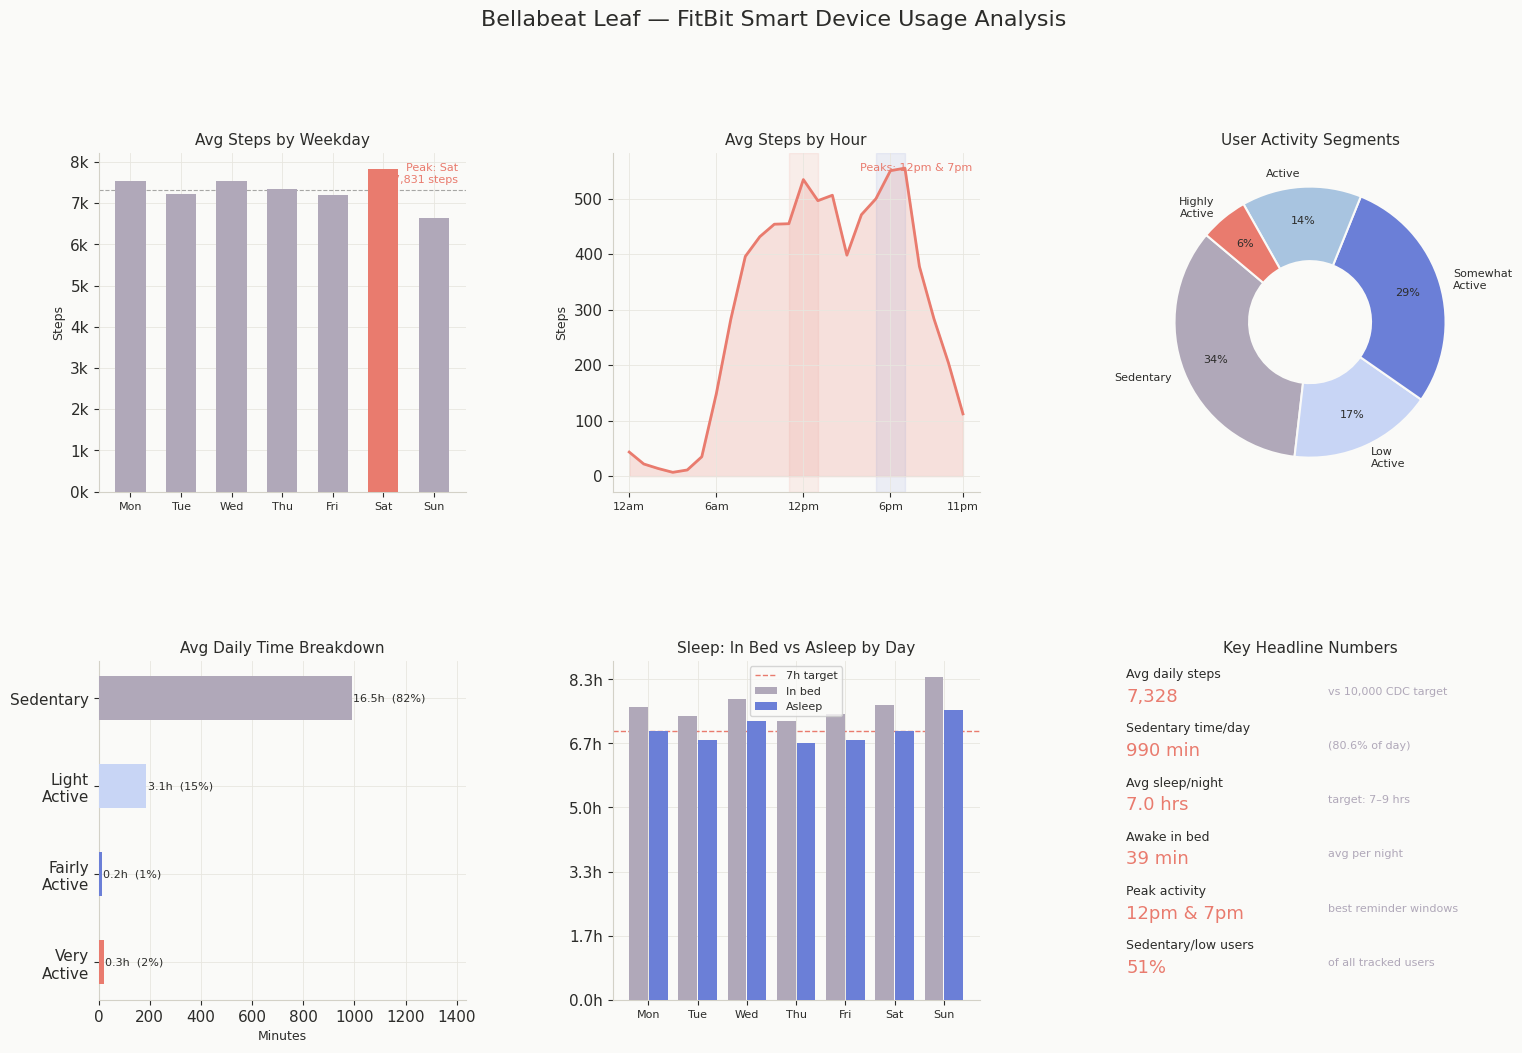

✓ Summary dashboard saved to Drive


In [15]:
fig = plt.figure(figsize=(18, 11), facecolor=BG)
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle(
    'Bellabeat Leaf — FitBit Smart Device Usage Analysis',
    fontsize=16, fontweight='500', y=1.01
)

# ── 1. Steps by day of week ───────────────────────────────────────────────────
ax1    = fig.add_subplot(gs[0, 0])
cols1  = [BRAND if v == steps_dow.max() else NEUTRAL
          for v in steps_dow.values]
ax1.bar([d[:3] for d in DAY_ORDER], steps_dow.values,
        color=cols1, zorder=3, width=0.6)
ax1.axhline(steps_dow.mean(), color=TEXT, linewidth=0.8,
            linestyle='--', alpha=0.4)
ax1.set_title('Avg Steps by Weekday', fontsize=11)
ax1.set_ylabel('Steps', fontsize=9)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.set_xticks(range(len(DAY_ORDER)))
ax1.set_xticklabels([d[:3] for d in DAY_ORDER], fontsize=8)
ax1.text(0.98, 0.97,
         f'Peak: {steps_dow.idxmax()[:3]}\n'
         f'{steps_dow.max():,.0f} steps',
         transform=ax1.transAxes, fontsize=8,
         color=BRAND, ha='right', va='top')

# ── 2. Hourly steps ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.fill_between(range(24), hourly_steps.values,
                 alpha=0.2, color=BRAND)
ax2.plot(range(24), hourly_steps.values,
         color=BRAND, linewidth=2)
ax2.axvspan(11, 13, color=BRAND,  alpha=0.1)
ax2.axvspan(17, 19, color=ACCENT, alpha=0.1)
ax2.set_title('Avg Steps by Hour', fontsize=11)
ax2.set_ylabel('Steps', fontsize=9)
ax2.set_xticks([0, 6, 12, 18, 23])
ax2.set_xticklabels(['12am', '6am', '12pm', '6pm', '11pm'],
                    fontsize=8)
ax2.text(0.98, 0.97, 'Peaks: 12pm & 7pm',
         transform=ax2.transAxes, fontsize=8,
         color=BRAND, ha='right', va='top')

# ── 3. User segments donut ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.pie(
    seg_counts,
    labels=[s.replace(' ', '\n') for s in SEGMENT_ORDER],
    autopct='%1.0f%%',
    colors=SEGMENT_COLORS,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=1.5),
    pctdistance=0.75,
    textprops={'fontsize': 8},
)
ax3.set_title('User Activity Segments', fontsize=11)

# ── 4. Sedentary breakdown ────────────────────────────────────────────────────
ax4    = fig.add_subplot(gs[1, 0])
labs4  = ['Sedentary', 'Light\nActive', 'Fairly\nActive',
          'Very\nActive']
vals4  = [avg_sed, avg_light, avg_fair, avg_very]
cols4  = [NEUTRAL, '#C8D5F5', ACCENT, BRAND]
ax4.barh(labs4, vals4, color=cols4, height=0.5, zorder=3)
for i, (v, tot) in enumerate(zip(vals4, [sum(vals4)] * 4)):
    ax4.text(v + 5, i,
             f'{v/60:.1f}h  ({v/tot*100:.0f}%)',
             va='center', fontsize=8)
ax4.set_title('Avg Daily Time Breakdown', fontsize=11)
ax4.set_xlabel('Minutes', fontsize=9)
ax4.set_xlim(0, avg_sed * 1.45)
ax4.invert_yaxis()

# ── 5. Sleep quality by day ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
x5  = range(len(DAY_ORDER))
ax5.bar([i - 0.2 for i in x5], sleep_dow['avg_in_bed'],
        width=0.38, label='In bed',  color=NEUTRAL, zorder=3)
ax5.bar([i + 0.2 for i in x5], sleep_dow['avg_asleep'],
        width=0.38, label='Asleep',  color=ACCENT,  zorder=3)
ax5.axhline(420, color=BRAND, linewidth=1,
            linestyle='--', label='7h target')
ax5.set_xticks(list(x5))
ax5.set_xticklabels([d[:3] for d in DAY_ORDER], fontsize=8)
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/60:.1f}h'))
ax5.set_title('Sleep: In Bed vs Asleep by Day', fontsize=11)
ax5.legend(fontsize=8)

# ── 6. Key stats callout ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

stats = [
    ('Avg daily steps',
     f"{da['total_steps'].mean():,.0f}",
     'vs 10,000 CDC target'),
    ('Sedentary time/day',
     f"{da['sedentary_minutes'].mean():.0f} min",
     f"({da['sedentary_pct'].mean():.1f}% of day)"),
    ('Avg sleep/night',
     f"{sleep['total_minutes_asleep'].mean()/60:.1f} hrs",
     'target: 7–9 hrs'),
    ('Awake in bed',
     f"{sleep['minutes_awake_in_bed'].mean():.0f} min",
     'avg per night'),
    ('Peak activity',
     '12pm & 7pm',
     'best reminder windows'),
    ('Sedentary/low users',
     '51%',
     'of all tracked users'),
]

for i, (label, value, sub) in enumerate(stats):
    y_pos = 0.95 - i * 0.16
    ax6.text(0.0,  y_pos,        label,
             fontsize=9,  color=TEXT,
             transform=ax6.transAxes)
    ax6.text(0.0,  y_pos - 0.07, value,
             fontsize=13, color=BRAND, fontweight='500',
             transform=ax6.transAxes)
    ax6.text(0.55, y_pos - 0.04, sub,
             fontsize=8,  color=NEUTRAL,
             transform=ax6.transAxes, va='center')

ax6.set_title('Key Headline Numbers', fontsize=11)

plt.savefig(f'{VIZ_PATH}/00_summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Summary dashboard saved to Drive')

---
## Key Findings & Leaf Marketing Recommendations

### Finding → Recommendation Framework

---

#### Recommendation 1 — Position Leaf as the antidote to
invisible inactivity

**Finding:** Users spend 81.8% of their tracked day sedentary
(avg 990 min/day). 71% of users exceed 75% sedentary time.
Even the least sedentary user is still 68% inactive. This is
a universal problem, not a niche one.

**Insight:** Most people underestimate how sedentary they are.
The problem is invisible until it is measured.

**Leaf action:** Market Leaf's haptic inactivity reminders as
its hero feature. Campaign: *"You sat for 3 hours without
noticing. Leaf noticed."* Target the Sedentary and Low Active
segments (51% of users) through Instagram and Google Display.

---

#### Recommendation 2 — Time Leaf notifications around the
two natural activity peaks

**Finding:** Activity peaks sharply at 12pm and 5–7pm every
day regardless of weekday. Users are nearly inactive between
midnight and 5am (avg 22 steps/hour).

**Insight:** Users already have natural movement windows. The
opportunity is to amplify them rather than build new habits
from scratch.

**Leaf action:** Set Leaf app notification defaults to fire at
10:30am and 4pm — just before the natural peaks. Campaign:
*"Leaf works with your rhythm, not against it."*

---

#### Recommendation 3 — Lead with sleep quality not duration

**Finding:** Users average 39 min awake in bed per night.
Sunday is worst (50.8 min). Sedentary minutes correlate
moderately with less sleep (r = -0.425). Burning more
calories correlates with less restlessness (r = -0.364).

**Insight:** The gap between time in bed and time asleep is
a pain point users feel but cannot quantify. Moving more
during the day demonstrably improves sleep quality.

**Leaf action:** Build a content marketing campaign around
sleep quality with the message: *"What you do during the
day shapes how you sleep at night. Leaf tracks both."*
Add a Sunday evening wind-down reminder tied to Leaf's
stress tracking feature.

---

## Limitations & Next Steps

**Limitations:**
- 35 users — too small for statistical significance
- 2016 data — wearable usage patterns have evolved
- No demographic data — gender and age unconfirmed
- Sleep data only available for 24 of 35 users
- Weight log only 13 users — excluded from analysis

**Recommended next steps:**
1. Collect current Bellabeat app data to validate trends
2. Survey Leaf users on which notification types drive
   most engagement
3. A/B test notification timing in the Bellabeat app
4. Segment analysis by age group once demographics
   are available